In [1]:
import os
os.makedirs("data/06_dataset_versions_updated", exist_ok=True)

In [2]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import files

In [3]:
dataset_v1 = pd.read_csv("dataset_v1_price_only_updated.csv")

print("dataset_v1 shape:", dataset_v1.shape)
dataset_v1.head()

dataset_v1 shape: (2247, 18)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,text_length_words,mda_status,primary_doc,past_return_10d,past_realized_vol_5d,past_realized_vol_10d,future_realized_vol_10d,abs_past_return_10d
0,AAPL,320193,2019-01-30,10-Q,0000320193-19-000010,2019,1,320193,32019319000010,AAPL_20190130_10-Q_000032019319000010.txt,8130,OK,a10-qq1201912292018.htm,0.031200,0.018383,0.016375,0.012985,0.031200
1,AAPL,320193,2019-05-01,10-Q,0000320193-19-000066,2019,2,320193,32019319000066,AAPL_20190501_10-Q_000032019319000066.txt,8286,OK,a10-qq220193302019.htm,0.007228,0.008079,0.010983,0.022134,0.007228
2,AAPL,320193,2019-07-31,10-Q,0000320193-19-000076,2019,3,320193,32019319000076,AAPL_20190731_10-Q_000032019319000076.txt,8166,OK,a10-qq320196292019.htm,0.020931,0.006725,0.011068,0.028255,0.020931
3,AAPL,320193,2020-01-29,10-Q,0000320193-20-000010,2020,1,320193,32019320000010,AAPL_20200129_10-Q_000032019320000010.txt,3926,OK,a10-qq1202012282019.htm,0.002303,0.020648,0.015755,0.021234,0.002303
4,AAPL,320193,2020-05-01,10-Q,0000320193-20-000052,2020,2,320193,32019320000052,AAPL_20200501_10-Q_000032019320000052.txt,5146,OK,a10-qq220203282020.htm,0.024802,0.020703,0.023482,0.012307,0.024802


In [4]:
TEXT_ZIP = "mda_text_files_updated.zip"
TEXT_DIR = Path("data/03_mda_text_updated")
TEXT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(TEXT_ZIP, "r") as zip_ref:
    zip_ref.extractall(TEXT_DIR)

print("Extracted text files:", len(list(TEXT_DIR.glob("*.txt"))))
print([x.name for x in list(TEXT_DIR.glob("*.txt"))[:10]])

Extracted text files: 2265
['ADBE_20200325_10-Q_000079634320000064.txt', 'ITW_20220211_10-K_000004982622000006.txt', 'UPS_20240807_10-Q_000109072724000045.txt', 'BMY_20190725_10-Q_000001427219000160.txt', 'PANW_20201119_10-Q_000132756720000041.txt', 'ABBV_20241104_10-Q_000155115224000040.txt', 'AMD_20210428_10-Q_000000248821000056.txt', 'MO_20231026_10-Q_000076418023000126.txt', 'NEM_20240429_10-Q_000116472724000031.txt', 'VRTX_20230802_10-Q_000087532023000021.txt']


In [5]:
lm = pd.read_csv("Loughran-McDonald_MasterDictionary_1993-2024.csv", low_memory=False)

print("Dictionary shape:", lm.shape)
print(lm.columns.tolist()[:20])
lm.head()

Dictionary shape: (86553, 17)
['Word', 'Seq_num', 'Word Count', 'Word Proportion', 'Average Proportion', 'Std Dev', 'Doc Count', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal', 'Constraining', 'Complexity', 'Syllables', 'Source']


,Word,Seq_num,Word Count,Word Proportion,Average Proportion,Std Dev,Doc Count,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Complexity,Syllables,Source
0,AARDVARK,1,755,2.955070e-08,1.945421e-08,4.078069e-06,140,0,0,0,0,0,0,0,0,2,12of12inf
1,AARDVARKS,2,3,1.174200e-10,8.060019e-12,8.919011e-09,1,0,0,0,0,0,0,0,0,2,12of12inf
2,ABACI,3,9,3.522600e-10,1.089343e-10,5.105359e-08,7,0,0,0,0,0,0,0,0,3,12of12inf
3,ABACK,4,29,1.135060e-09,6.197922e-10,1.539279e-07,28,0,0,0,0,0,0,0,0,2,12of12inf
4,ABACUS,5,9620,3.765268e-07,3.825261e-07,3.421836e-05,1295,0,0,0,0,0,0,0,0,3,12of12inf


In [6]:
possible_word_cols = ["Word", "word", "TERM", "Term"]

word_col = None
for c in possible_word_cols:
    if c in lm.columns:
        word_col = c
        break

if word_col is None:
    raise ValueError("Could not find the dictionary word column.")

lm[word_col] = lm[word_col].astype(str).str.upper().str.strip()

negative_words = set(lm.loc[lm["Negative"] > 0, word_col])
positive_words = set(lm.loc[lm["Positive"] > 0, word_col])
uncertainty_words = set(lm.loc[lm["Uncertainty"] > 0, word_col])

print("Negative words:", len(negative_words))
print("Positive words:", len(positive_words))
print("Uncertainty words:", len(uncertainty_words))

Negative words: 2345
Positive words: 347
Uncertainty words: 297


In [7]:
def tokenize_text(text):
    return re.findall(r"[A-Za-z]+", str(text).upper())

def lm_features_from_text(text):
    tokens = tokenize_text(text)
    total_words = len(tokens)

    if total_words == 0:
        return {
            "lm_negative": np.nan,
            "lm_positive": np.nan,
            "lm_uncertainty": np.nan,
            "lm_total_words": 0,
            "lm_net_sentiment": np.nan
        }

    neg_count = sum(1 for t in tokens if t in negative_words)
    pos_count = sum(1 for t in tokens if t in positive_words)
    unc_count = sum(1 for t in tokens if t in uncertainty_words)

    lm_negative = neg_count / total_words
    lm_positive = pos_count / total_words
    lm_uncertainty = unc_count / total_words
    lm_net_sentiment = lm_positive - lm_negative

    return {
        "lm_negative": lm_negative,
        "lm_positive": lm_positive,
        "lm_uncertainty": lm_uncertainty,
        "lm_total_words": total_words,
        "lm_net_sentiment": lm_net_sentiment
    }

def lm_features_from_file(path):
    if not path.exists():
        return {
            "lm_negative": np.nan,
            "lm_positive": np.nan,
            "lm_uncertainty": np.nan,
            "lm_total_words": np.nan,
            "lm_net_sentiment": np.nan
        }

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    return lm_features_from_text(text)

In [8]:
print(dataset_v1.columns.tolist())

if "mda_path" not in dataset_v1.columns:
    raise ValueError("mda_path column missing from dataset_v1_price_only_updated.csv")

['ticker', 'cik', 'filing_date', 'filing_type', 'accession_number', 'year', 'quarter', 'cik_nolead', 'acc_nodash', 'mda_path', 'text_length_words', 'mda_status', 'primary_doc', 'past_return_10d', 'past_realized_vol_5d', 'past_realized_vol_10d', 'future_realized_vol_10d', 'abs_past_return_10d']


In [9]:
features = []
dropped_step6 = []

for i, row in dataset_v1.iterrows():
    fname = os.path.basename(str(row["mda_path"]).strip())
    path = TEXT_DIR / fname

    if not path.exists():
        dropped_step6.append({
            "ticker": row.get("ticker", ""),
            "filing_date": row.get("filing_date", ""),
            "mda_path": str(row["mda_path"]).strip(),
            "reason": "MISSING_TEXT_FILE"
        })
        feats = {
            "lm_negative": np.nan,
            "lm_positive": np.nan,
            "lm_uncertainty": np.nan,
            "lm_total_words": np.nan,
            "lm_net_sentiment": np.nan
        }
    else:
        feats = lm_features_from_file(path)

    features.append(feats)

    if (i + 1) % 250 == 0 or (i + 1) == len(dataset_v1):
        print(f"Processed {i+1}/{len(dataset_v1)}")

Processed 250/2247
Processed 500/2247
Processed 750/2247
Processed 1000/2247
Processed 1250/2247
Processed 1500/2247
Processed 1750/2247
Processed 2000/2247
Processed 2247/2247


In [10]:
features_df = pd.DataFrame(features)

dataset_v2 = pd.concat([dataset_v1.reset_index(drop=True), features_df], axis=1)

print("dataset_v2 shape before dropping missing text features:", dataset_v2.shape)
dataset_v2.head()

dataset_v2 shape before dropping missing text features: (2247, 23)


,ticker,cik,filing_date,filing_type,accession_number,year,quarter,cik_nolead,acc_nodash,mda_path,...,past_return_10d,past_realized_vol_5d,past_realized_vol_10d,future_realized_vol_10d,abs_past_return_10d,lm_negative,lm_positive,lm_uncertainty,lm_total_words,lm_net_sentiment
0,AAPL,320193,2019-01-30,10-Q,0000320193-19-000010,2019,1,320193,32019319000010,AAPL_20190130_10-Q_000032019319000010.txt,...,0.031200,0.018383,0.016375,0.012985,0.031200,0.040979,0.005424,0.034711,8297,-0.035555
1,AAPL,320193,2019-05-01,10-Q,0000320193-19-000066,2019,2,320193,32019319000066,AAPL_20190501_10-Q_000032019319000066.txt,...,0.007228,0.008079,0.010983,0.022134,0.007228,0.040265,0.005329,0.033989,8444,-0.034936
2,AAPL,320193,2019-07-31,10-Q,0000320193-19-000076,2019,3,320193,32019319000076,AAPL_20190731_10-Q_000032019319000076.txt,...,0.020931,0.006725,0.011068,0.028255,0.020931,0.040797,0.005400,0.034677,8334,-0.035397
3,AAPL,320193,2020-01-29,10-Q,0000320193-20-000010,2020,1,320193,32019320000010,AAPL_20200129_10-Q_000032019320000010.txt,...,0.002303,0.020648,0.015755,0.021234,0.002303,0.005647,0.001694,0.010164,3542,-0.003953
4,AAPL,320193,2020-05-01,10-Q,0000320193-20-000052,2020,2,320193,32019320000052,AAPL_20200501_10-Q_000032019320000052.txt,...,0.024802,0.020703,0.023482,0.012307,0.024802,0.008942,0.002835,0.009378,4585,-0.006107


In [11]:
dataset_v2 = dataset_v2.dropna(subset=[
    "lm_uncertainty",
    "lm_negative",
    "lm_positive"
]).copy()

print("dataset_v2 shape after dropping missing text features:", dataset_v2.shape)

dataset_v2 shape after dropping missing text features: (2247, 23)


In [12]:
dropped_step6_df = pd.DataFrame(dropped_step6)

dropped_step6_df.to_csv(
    "data/06_dataset_versions_updated/dropped_step6_rows_updated.csv",
    index=False
)

print("Dropped Step 6 rows:", len(dropped_step6_df))
if len(dropped_step6_df) > 0:
    print(dropped_step6_df["reason"].value_counts(dropna=False))
dropped_step6_df.head()

Dropped Step 6 rows: 0


""


In [13]:
dataset_v2.to_csv(
    "data/06_dataset_versions_updated/dataset_v2_price_plus_dictionary_updated.csv",
    index=False
)

print("Saved: data/06_dataset_versions_updated/dataset_v2_price_plus_dictionary_updated.csv")

Saved: data/06_dataset_versions_updated/dataset_v2_price_plus_dictionary_updated.csv


In [14]:
dataset_v2[
    ["lm_negative", "lm_positive", "lm_uncertainty", "lm_net_sentiment", "lm_total_words"]
].describe()

,lm_negative,lm_positive,lm_uncertainty,lm_net_sentiment,lm_total_words
count,2247.000000,2247.000000,2247.000000,2247.000000,2247.000000
mean,0.013002,0.006123,0.012925,-0.006880,8847.088117
std,0.008087,0.002935,0.005848,0.007859,6401.518039
min,0.000000,0.000000,0.000000,-0.042519,765.000000
25%,0.007845,0.003883,0.009264,-0.009640,4864.500000
50%,0.011055,0.005614,0.011862,-0.005495,7483.000000
75%,0.015604,0.007977,0.014806,-0.002172,10836.000000
max,0.058629,0.017555,0.046229,0.013098,54925.000000


In [15]:
dataset_v2[
    ["lm_negative", "lm_positive", "lm_uncertainty", "lm_net_sentiment", "lm_total_words"]
].describe()

,lm_negative,lm_positive,lm_uncertainty,lm_net_sentiment,lm_total_words
count,2247.000000,2247.000000,2247.000000,2247.000000,2247.000000
mean,0.013002,0.006123,0.012925,-0.006880,8847.088117
std,0.008087,0.002935,0.005848,0.007859,6401.518039
min,0.000000,0.000000,0.000000,-0.042519,765.000000
25%,0.007845,0.003883,0.009264,-0.009640,4864.500000
50%,0.011055,0.005614,0.011862,-0.005495,7483.000000
75%,0.015604,0.007977,0.014806,-0.002172,10836.000000
max,0.058629,0.017555,0.046229,0.013098,54925.000000


In [16]:
print("Share with lm_negative == 0:", (dataset_v2["lm_negative"] == 0).mean())
print("Share with lm_positive == 0:", (dataset_v2["lm_positive"] == 0).mean())
print("Share with lm_uncertainty == 0:", (dataset_v2["lm_uncertainty"] == 0).mean())

Share with lm_negative == 0: 0.0017801513128615932
Share with lm_positive == 0: 0.004895416110369382
Share with lm_uncertainty == 0: 0.0004450378282153983


In [17]:
corr_cols = [
    "past_return_10d",
    "abs_past_return_10d",
    "past_realized_vol_5d",
    "past_realized_vol_10d",
    "lm_negative",
    "lm_positive",
    "lm_uncertainty",
    "lm_net_sentiment",
    "lm_total_words",
    "future_realized_vol_10d"
]

corr = dataset_v2[corr_cols].corr()
print(corr)

                         past_return_10d  abs_past_return_10d  \
past_return_10d                 1.000000             0.296161   
abs_past_return_10d             0.296161             1.000000   
past_realized_vol_5d            0.031321             0.456391   
past_realized_vol_10d           0.066715             0.538952   
lm_negative                    -0.010691            -0.058049   
lm_positive                    -0.024940            -0.074211   
lm_uncertainty                 -0.004540             0.011542   
lm_net_sentiment                0.001689             0.032023   
lm_total_words                  0.005495            -0.032994   
future_realized_vol_10d        -0.075661             0.305732   

                         past_realized_vol_5d  past_realized_vol_10d  \
past_return_10d                      0.031321               0.066715   
abs_past_return_10d                  0.456391               0.538952   
past_realized_vol_5d                 1.000000               0.839108

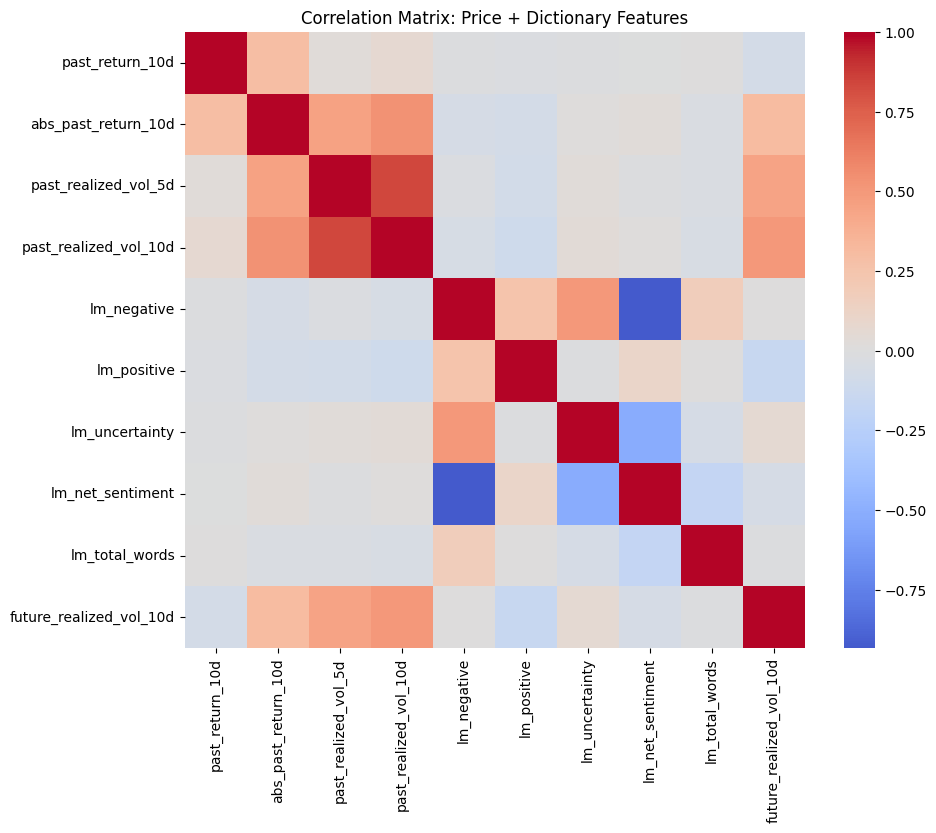

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Price + Dictionary Features")
plt.show()

In [19]:
print("Correlation with document length:")
print(dataset_v2[
    ["lm_negative", "lm_positive", "lm_uncertainty", "lm_net_sentiment", "lm_total_words"]
].corr()["lm_total_words"])

Correlation with document length:
lm_negative         0.170359
lm_positive         0.004340
lm_uncertainty     -0.064183
lm_net_sentiment   -0.173680
lm_total_words      1.000000
Name: lm_total_words, dtype: float64


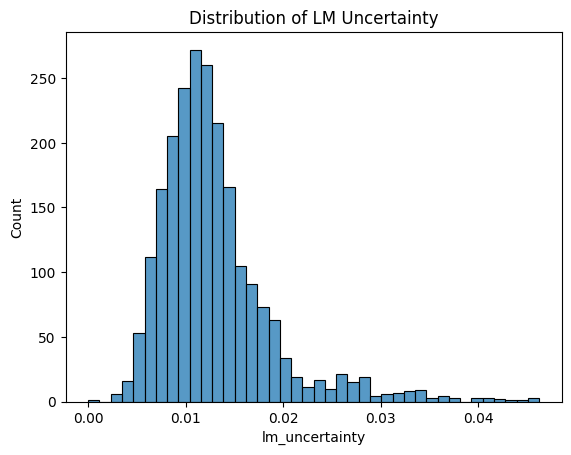

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(dataset_v2["lm_uncertainty"], bins=40)
plt.title("Distribution of LM Uncertainty")
plt.show()

In [21]:
print("Correlation with future realized volatility:")
print(dataset_v2[
    ["lm_negative", "lm_positive", "lm_uncertainty", "lm_net_sentiment", "future_realized_vol_10d"]
].corr()["future_realized_vol_10d"])

Correlation with future realized volatility:
lm_negative                0.005396
lm_positive               -0.154746
lm_uncertainty             0.063090
lm_net_sentiment          -0.063333
future_realized_vol_10d    1.000000
Name: future_realized_vol_10d, dtype: float64


In [22]:
print("Step 6 summary")
print("-" * 40)
print("Step 5 input rows:", len(dataset_v1))
print("Step 6 final rows:", len(dataset_v2))
print("Dropped rows:", len(dropped_step6_df))

print("\nMissing values in textual features:")
print(dataset_v2[
    ["lm_negative", "lm_positive", "lm_uncertainty", "lm_net_sentiment", "lm_total_words"]
].isna().sum())

Step 6 summary
----------------------------------------
Step 5 input rows: 2247
Step 6 final rows: 2247
Dropped rows: 0

Missing values in textual features:
lm_negative         0
lm_positive         0
lm_uncertainty      0
lm_net_sentiment    0
lm_total_words      0
dtype: int64


In [23]:
print(dataset_v2["lm_total_words"].describe())

count     2247.000000
mean      8847.088117
std       6401.518039
min        765.000000
25%       4864.500000
50%       7483.000000
75%      10836.000000
max      54925.000000
Name: lm_total_words, dtype: float64


In [24]:
dataset_v2[["text_length_words", "lm_total_words"]].describe()
print(dataset_v2[["text_length_words", "lm_total_words"]].corr())

                   text_length_words  lm_total_words
text_length_words           1.000000        0.906508
lm_total_words              0.906508        1.000000


In [25]:
dataset_v2[
    ["ticker", "filing_date", "mda_path", "lm_negative", "lm_positive", "lm_uncertainty", "lm_total_words"]
].head(10)

,ticker,filing_date,mda_path,lm_negative,lm_positive,lm_uncertainty,lm_total_words
0,AAPL,2019-01-30,AAPL_20190130_10-Q_000032019319000010.txt,0.040979,0.005424,0.034711,8297
1,AAPL,2019-05-01,AAPL_20190501_10-Q_000032019319000066.txt,0.040265,0.005329,0.033989,8444
2,AAPL,2019-07-31,AAPL_20190731_10-Q_000032019319000076.txt,0.040797,0.005400,0.034677,8334
3,AAPL,2020-01-29,AAPL_20200129_10-Q_000032019320000010.txt,0.005647,0.001694,0.010164,3542
4,AAPL,2020-05-01,AAPL_20200501_10-Q_000032019320000052.txt,0.008942,0.002835,0.009378,4585
5,AAPL,2020-07-31,AAPL_20200731_10-Q_000032019320000062.txt,0.007425,0.001310,0.009827,4579
6,AAPL,2021-01-28,AAPL_20210128_10-Q_000032019321000010.txt,0.002940,0.002673,0.011494,3741
7,AAPL,2021-04-29,AAPL_20210429_10-Q_000032019321000056.txt,0.003401,0.003643,0.010444,4117
8,AAPL,2021-07-28,AAPL_20210728_10-Q_000032019321000065.txt,0.002994,0.004836,0.010134,4342
9,AAPL,2022-01-28,AAPL_20220128_10-Q_000032019322000007.txt,0.005368,0.002301,0.011503,2608


In [26]:
from google.colab import files

files.download("data/06_dataset_versions_updated/dataset_v2_price_plus_dictionary_updated.csv")
files.download("data/06_dataset_versions_updated/dropped_step6_rows_updated.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>